#**Lab 0 - Exercises**

#Exercise 4: NumPy Array Operations


In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Task 1: Create a 5x5 matrix where border elements are 1 and interior is
mat = np.ones((5, 5))
mat[1:-1, 1:-1] = 0

print(mat)

[[1. 1. 1. 1. 1.]
 [1. 0. 0. 0. 1.]
 [1. 0. 0. 0. 1.]
 [1. 0. 0. 0. 1.]
 [1. 1. 1. 1. 1.]]


In [3]:
# Task 2: Normalize a random array
np.random.seed(42)
random_data = np.random.randn(100, 3)

normalized = (random_data - random_data.mean(axis=0)) / random_data.std(axis=0)

print(normalized.mean(axis=0))
print(normalized.std(axis=0))

[-2.60902411e-17  1.55431223e-17 -8.88178420e-18]
[1. 1. 1.]


In [8]:
X = np.random.randn(50, 3)
true_theta = np.array([2.5, -1.2, 3.7])
y = X @ true_theta + np.random.randn(50) * 0.1

In [9]:
# Task 3: Implement linear regression solution using normal equation
theta_hat = np.linalg.inv(X.T @ X) @ X.T @ y

print("estimated coefficients:", theta_hat)
print("true coefficients:", true_theta)

Estimated coefficients: [ 2.51723721 -1.19783796  3.72399266]
True coefficients: [ 2.5 -1.2  3.7]


#Exercise 5: Pandas Data Analysis

In [2]:
import pandas as pd
import numpy as np

np.random.seed(42)
n_students = 200

data = {
    'student_id': range(1000, 1000 + n_students),
    'major': np.random.choice(['CS', 'Math', 'Physics', 'Biology'], n_students),
    'year': np.random.choice([1, 2, 3, 4], n_students),
    'exam_score': np.random.normal(75, 10, n_students).clip(0, 100),
    'assignments_completed': np.random.randint(0, 11, n_students),
    'hours_studied': np.random.normal(15, 5, n_students).clip(1, 40)
}

df = pd.DataFrame(data)

df.loc[np.random.choice(n_students, 10), 'exam_score'] = np.nan
df.loc[np.random.choice(n_students, 5), 'hours_studied'] = np.nan

In [3]:
# Task 1: Data Cleaning and Exploration
print(df.info())
print(df.describe())
print(df.shape)
print("The missing values are:")
print(df.isnull().sum())

# Fill missing exam_score with mean per major
df['exam_score'] = df['exam_score'].fillna(df.groupby('major')['exam_score'].transform('mean'))

# Fill missing hours_studied with median per year
df['hours_studied'] = df['hours_studied'].fillna(df.groupby('year')['hours_studied'].transform('median'))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   student_id             200 non-null    int64  
 1   major                  200 non-null    object 
 2   year                   200 non-null    int64  
 3   exam_score             190 non-null    float64
 4   assignments_completed  200 non-null    int64  
 5   hours_studied          195 non-null    float64
dtypes: float64(2), int64(3), object(1)
memory usage: 9.5+ KB
None
        student_id        year  exam_score  assignments_completed  \
count   200.000000  200.000000  190.000000             200.000000   
mean   1099.500000    2.615000   75.510638               4.700000   
std      57.879185    1.159091    9.582797               3.239207   
min    1000.000000    1.000000   42.587327               0.000000   
25%    1049.750000    2.000000   68.206910               2.000000   

In [5]:
# Task 2: Analysis
# Avg exam score by major
print(df.groupby('major')['exam_score'].mean())

# Major with the highest avg score
best_major = df.groupby('major')['exam_score'].mean().idxmax()
print("Best major:", best_major)

# Correlation
correlation =(df[['hours_studied', 'exam_score']].corr())
print ("Correlation:", correlation)

major
Biology    75.503150
CS         76.425184
Math       74.683689
Physics    75.406509
Name: exam_score, dtype: float64
Best major: CS
Correlation:                hours_studied  exam_score
hours_studied       1.000000   -0.055981
exam_score         -0.055981    1.000000


Performance Categories Column



In [6]:
def categorize(score):
    if score > 90:
        return "Excellent"
    elif score >= 80:
        return "Good"
    elif score >= 70:
        return "Average"
    else:
        return "Needs Improvement"

df['performance'] = df['exam_score'].apply(categorize)

In [8]:
# Task 3: Advanced Analysis
stats = df.groupby(['major', 'year']).agg(
    num_of_students=('student_id', 'count'),
    avg_examscore=('exam_score', 'mean'),
    avg_hours=('hours_studied', 'mean')
)

print(stats)

              num_of_students  avg_examscore  avg_hours
major   year                                           
Biology 1                  13      76.570059  12.677806
        2                  12      74.899613  13.426372
        3                  14      80.178476  14.486815
        4                  15      70.697689  14.253944
CS      1                  12      77.098194  13.039480
        2                   7      76.155936  13.995784
        3                   9      72.347626  15.039892
        4                  18      78.119997  16.275541
Math    1                  11      74.053167  19.001215
        2                   9      81.226714  12.345468
        3                  10      72.017537  15.175871
        4                  16      73.103066  17.419175
Physics 1                  13      77.828686  13.489911
        2                  12      73.277734  14.616778
        3                  17      73.134319  14.199901
        4                  12      78.130194  15

Top 5 Students


In [9]:
top_five_students = df.sort_values('exam_score', ascending=False).head(5)
print(top_five_students)

     student_id    major  year  exam_score  assignments_completed  \
57         1057       CS     2  100.000000                      8   
27         1027     Math     2  100.000000                      4   
68         1068  Biology     3   98.146586                      1   
82         1082       CS     2   96.439441                      0   
132        1132       CS     4   96.330334                     10   

     hours_studied performance  
57       11.870035   Excellent  
27        2.716265   Excellent  
68       11.379991   Excellent  
82        7.378547   Excellent  
132      17.546891   Excellent  


Pivot Table

In [18]:

pivot = df.pivot_table(values='exam_score', index='major', columns='year', aggfunc='mean')
print(pivot)

year             1          2          3          4
major                                              
Biology  76.570059  74.899613  80.178476  70.697689
CS       77.098194  76.155936  72.347626  78.119997
Math     74.053167  81.226714  72.017537  73.103066
Physics  77.828686  73.277734  73.134319  78.130194


#Exercise 6: Data Visualization

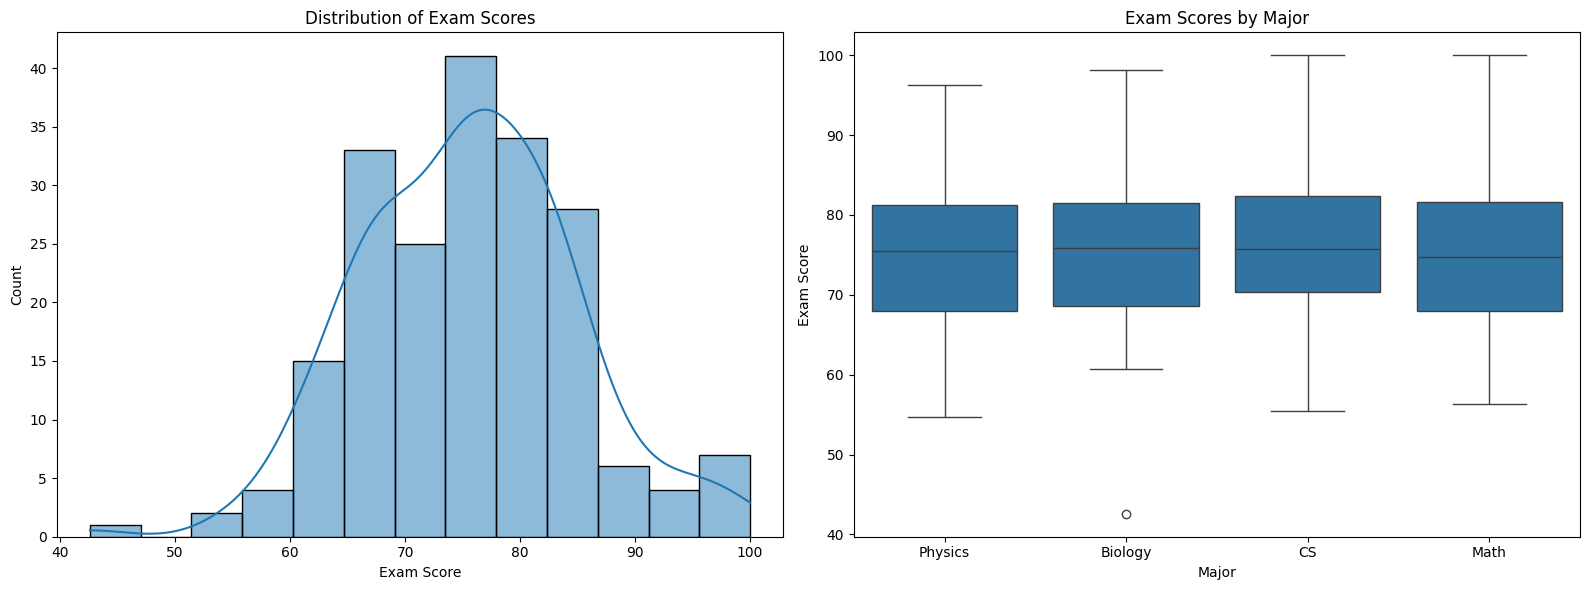

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create figure with two subplots
fig, axis = plt.subplots(1, 2, figsize=(16, 6))

# Histogram with KDE
sns.histplot(data=df, x='exam_score', kde=True, ax=axis[0])
axis[0].set_title('Distribution of Exam Scores')
axis[0].set_xlabel('Exam Score')
axis[0].set_ylabel('Count')

# Box plot
sns.boxplot(data=df, x='major', y='exam_score', ax=axis[1])
axis[1].set_title('Exam Scores by Major')
axis[1].set_xlabel('Major')
axis[1].set_ylabel('Exam Score')

plt.tight_layout()
plt.show()



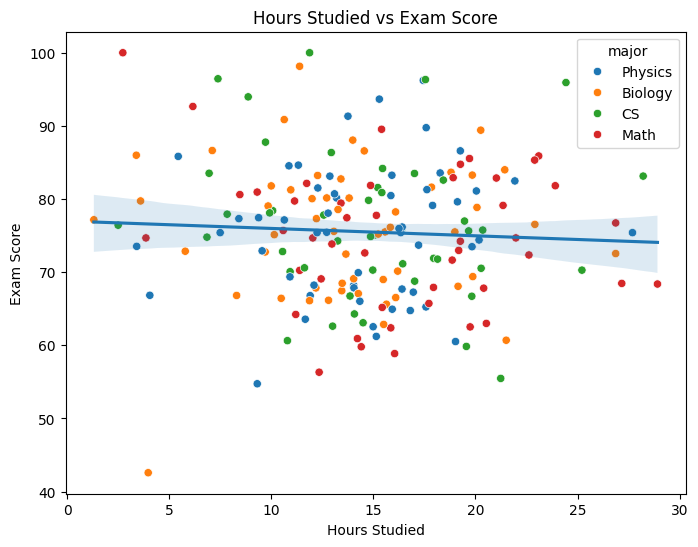

In [13]:
# Task 2: Relationship Visualization
# Scatter plot
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x='hours_studied',
    y='exam_score',
    hue='major'
)

# Regression line
sns.regplot(
    data=df,
    x='hours_studied',
    y='exam_score',
    scatter=False
)

plt.xlabel('Hours Studied')
plt.ylabel('Exam Score')
plt.title('Hours Studied vs Exam Score')
plt.show()

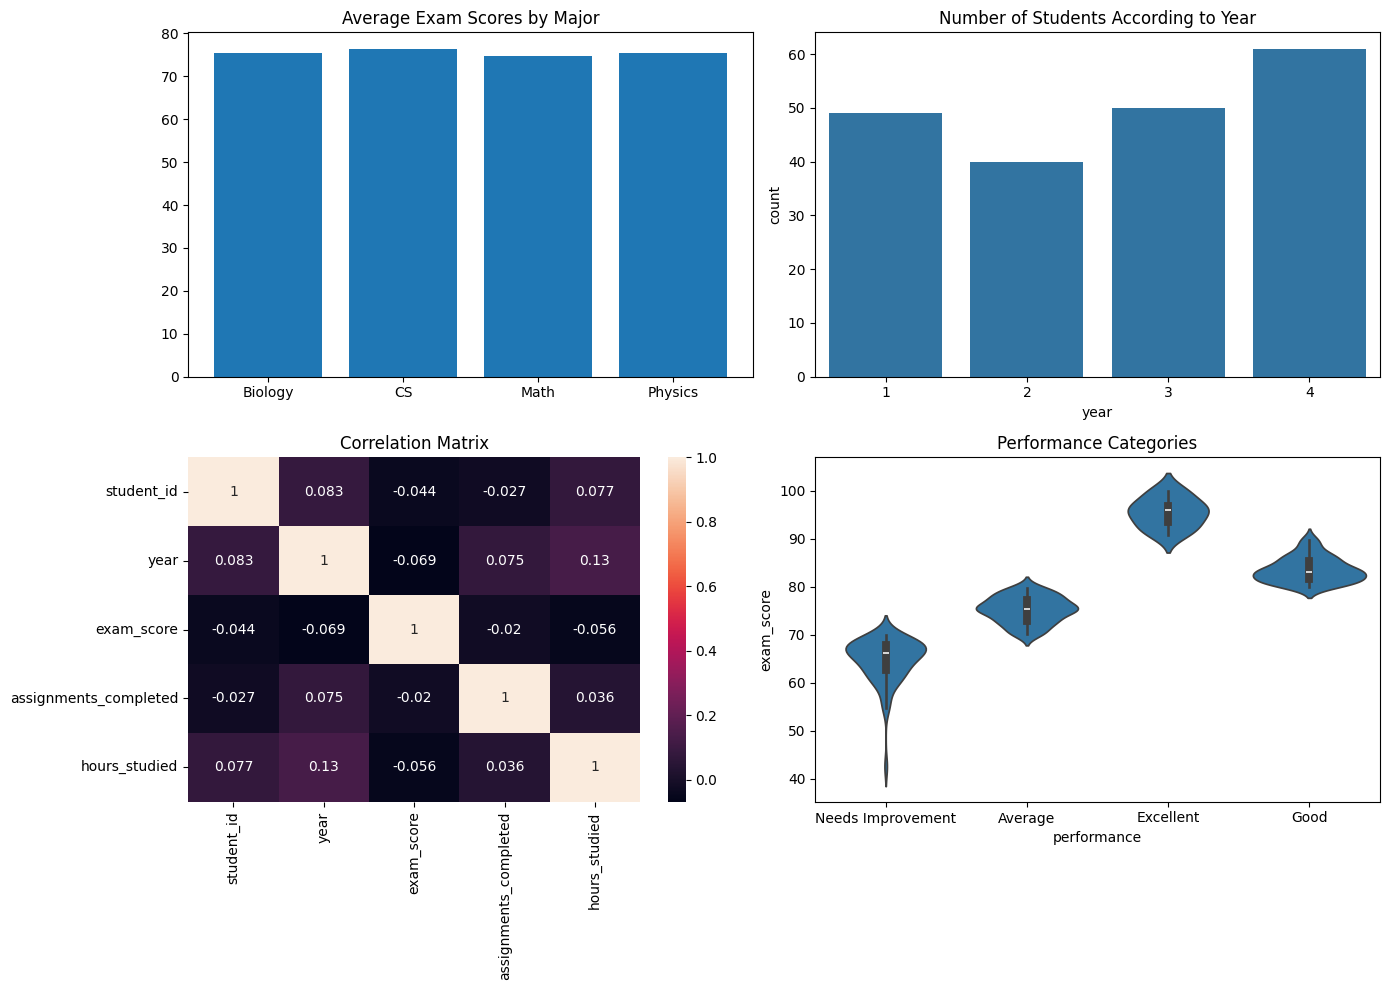

In [14]:
#Task 3: Advanced Dashboard
# Dashboard
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Average exam score by major
avg_scores = df.groupby('major')['exam_score'].mean()

axes[0, 0].bar(avg_scores.index, avg_scores.values)
axes[0, 0].set_title('Average Exam Scores by Major')

# Num of students by year
sns.countplot(data=df, x='year', ax=axes[0, 1])
axes[0, 1].set_title('Number of Students According to Year')

# Heatmap
correlation = df.select_dtypes(include=np.number).corr()

sns.heatmap(
    correlation,
    annot=True,
    ax=axes[1, 0]
)

axes[1, 0].set_title('Correlation Matrix')

# Violin plot
sns.violinplot(
    data=df,
    x='performance',
    y='exam_score',
    ax=axes[1, 1]
)

axes[1, 1].set_title('Performance Categories')

plt.tight_layout()
plt.show()

#Exercise 7: Integration Challenge

In [3]:

#Combine NumPy, Pandas, and Matplotlib to solve a mini data science problem.

# Scenario: You're analyzing customer data for an e-commerce company.
# Generate synthetic data and provide insights.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)
n_customers = 500

# Generate customer data
ages = np.random.randint(18, 70, n_customers)
income = np.random.normal(50000, 20000, n_customers).clip(15000, 150000)
purchase_freq = np.random.poisson(5, n_customers)
avg_purchase_value = np.random.normal(100, 30, n_customers).clip(10, 500)

# Create DataFrame
customers = pd.DataFrame({
    'age': ages,
    'income': income,
    'purchase_frequency': purchase_freq,
    'avg_purchase_value': avg_purchase_value
})


In [5]:
# Churn Risk
max_frequency = customers['purchase_frequency'].max()

customers['churn_risk'] = (1 - customers['purchase_frequency'] / max_frequency)

# Customer Lifetime Value(CLV)
customers['CLV'] = (customers['purchase_frequency']* customers['avg_purchase_value']* (1 + customers['churn_risk']))
customers.head()




,age,income,purchase_frequency,avg_purchase_value,churn_risk,CLV
0,56,92443.123940,7,94.527456,0.416667,937.397271
1,69,70649.305211,2,100.932279,0.833333,370.085023
2,46,19612.600681,3,79.699876,0.750000,418.424348
3,32,40315.318543,2,130.137787,0.833333,477.171887
4,60,75338.222984,8,102.904845,0.333333,1097.651683


In [6]:
# Age groups

bins = [18, 25, 35, 50, 70]
labels = ['18-25', '26-35', '36-50', '51-70']

customers['age_group'] = pd.cut(
    customers['age'],
    bins=bins,
    labels=labels,
    include_lowest=True
)

customers.head()

,age,income,purchase_frequency,avg_purchase_value,churn_risk,CLV,age_group
0,56,92443.123940,7,94.527456,0.416667,937.397271,51-70
1,69,70649.305211,2,100.932279,0.833333,370.085023,51-70
2,46,19612.600681,3,79.699876,0.750000,418.424348,36-50
3,32,40315.318543,2,130.137787,0.833333,477.171887,26-35
4,60,75338.222984,8,102.904845,0.333333,1097.651683,51-70


In [7]:

# TODO: For each age group, calculate:
#       - Number of customers
#       - Average income
#       - Average CLV
#       - Total CLV

age_group_stats = customers.groupby('age_group').agg(
    num_customers=('age', 'count'),
    avg_income=('income', 'mean'),
    avg_clv=('CLV', 'mean'),
    total_clv=('CLV', 'sum')
)

print(age_group_stats)

           num_customers    avg_income     avg_clv      total_clv
age_group                                                        
18-25                 81  50634.018330  718.371170   58188.064760
26-35                 73  48747.148046  747.738562   54584.915035
36-50                160  48516.895668  732.796612  117247.457917
51-70                186  50713.163384  762.693498  141860.990683


/tmp/ipykernel_470/1837980892.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_group_stats = customers.groupby('age_group').agg(


In [8]:
# Top 10% of customers by CLV
clv_cutoff = customers['CLV'].quantile(0.90)

top_customers = customers[customers['CLV'] >= clv_cutoff]

print(top_customers.head())
print(f"Number of top customers: {len(top_customers)}")

    age        income  purchase_frequency  avg_purchase_value  churn_risk  \
6    38  58876.388563                  10          110.331527    0.166667   
9    40  48809.492879                  10          110.228581    0.166667   
19   41  21282.756976                   8          119.651218    0.333333   
24   38  53981.193911                   8          120.320786    0.333333   
57   64  45956.146951                   7          135.470585    0.416667   

            CLV age_group  
6   1287.201143     36-50  
9   1286.000108     36-50  
19  1276.279663     36-50  
24  1283.421714     36-50  
57  1343.416638     51-70  
Number of top customers: 50


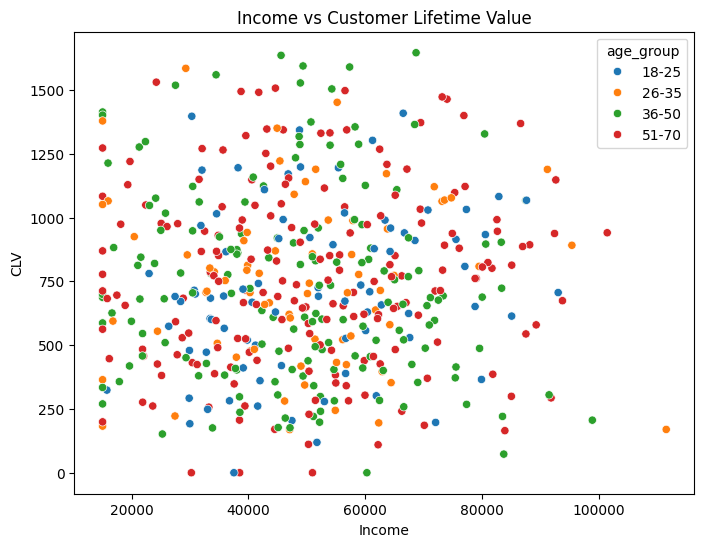

In [11]:
# Scatter plot of income vs CLV (color by age group)
import seaborn as sns

plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=customers,
    x='income',
    y='CLV',
    hue='age_group'
)

plt.title('Income vs Customer Lifetime Value')
plt.xlabel('Income')
plt.ylabel('CLV')
plt.show()

/tmp/ipykernel_470/3041432319.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  average_clv = customers.groupby('age_group')['CLV'].mean()


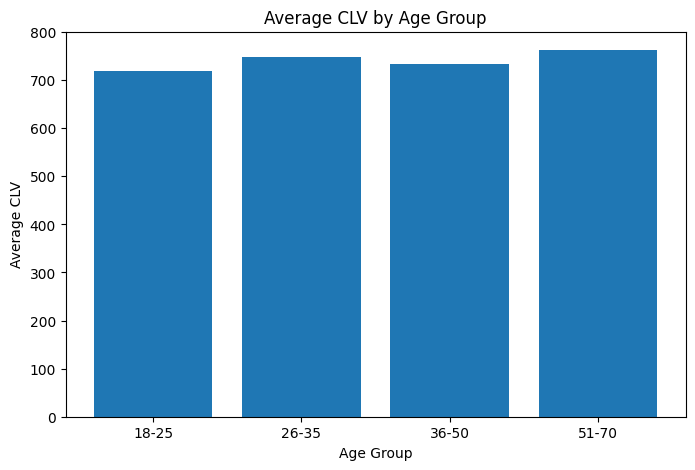

In [12]:
#Bar chart of average CLV by age group
average_clv = customers.groupby('age_group')['CLV'].mean()

plt.figure(figsize=(8, 5))

plt.bar(average_clv.index, average_clv.values)

plt.title('Average CLV by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Average CLV')

plt.show()

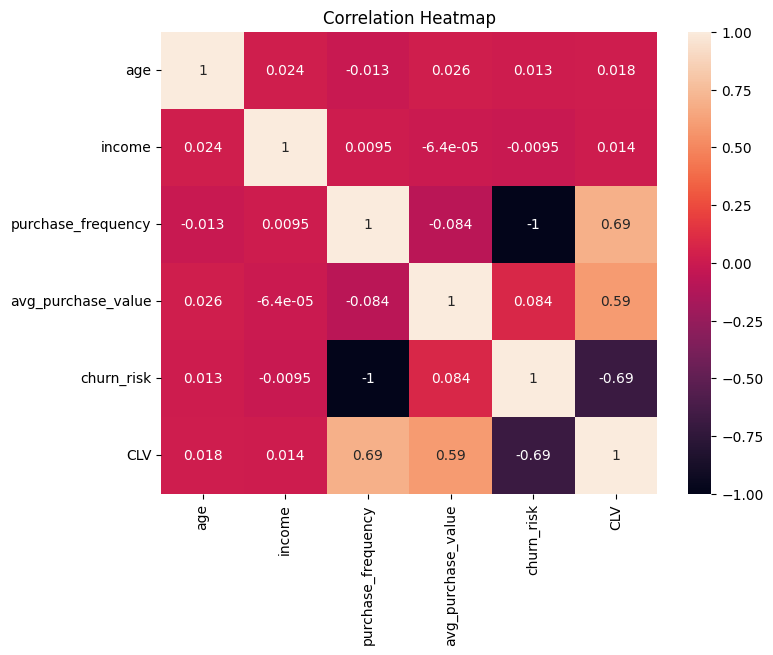

In [13]:
#Correlation heatmap
correlation = customers.select_dtypes(include=np.number).corr()

plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation,
    annot=True
)

plt.title('Correlation Heatmap')

plt.show()

## Analysis and Recommendations

From the age group analysis, the 51 to 70 age group had the highest average CLV (762.69) and the highest total CLV (141,860.99). Although the 26 to 35 age group had the lowest average income, their average CLV was still fairly high. The 36 to 50 and 51 to 70 age groups contributed the most total CLV because they had the largest number of customers. Looking at the correlation heatmap, purchase frequency had the strongest positive relationship with CLV (0.69). This suggests that customers who buy more often tend to generate more value for the company. Average purchase value was also positively related to CLV (0.59). On the other hand, churn risk showed a strong negative relationship with CLV (-0.69) meaning that customers who are more likely to stop purchasing tend to have lower lifetime value.

Based on these results, the company should focus on encouraging repeat purchases and reducing customer churn. Loyalty programs, discounts for returning customers, and personalized offers could help increase customer lifetime value. The 51 to 70 age group may also be worth targeting since they generated the highest overall value in this dataset.